# The dynamics of informativeness (Section 5)

Measures how much the price tells us about the outcome at a fixed number of days before the market
closes, and how quickly that information builds up. This notebook produces Figure 1 (share of
uncertainty resolved by days before close), Figure 2 (information gained per day) and Table 5
(the four-month cohort at selected horizons, with bootstrap standard errors).

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from common import OUTPUT_DIR, binary_entropy
from bootstrap import *

## Information at a given horizon

`information_curve` computes $I(Y; P_d)$, the information in the price $d$ days before close, for
$d = 1, \dots, D$. Three choices keep the curve comparable across horizons:

- **Balanced cohorts.** Every closed market has a price one day before close, but only long-lived
  markets have one four months before. Plotting all markets would change the sample at every horizon.
  Instead, the cohort for lifetime $D$ keeps only markets that traded for at least $D$ days, so the
  same markets appear at every horizon from $D$ days down to one.
- **A 48-hour buffer.** Markets must also have traded for 48 hours before the cohort's earliest
  horizon. Otherwise, markets that only just clear the cutoff would enter the curve on their opening
  day, when the price is still mostly the initial quote, which would drag the left end of the curve down.
- **One price per market per day.** For each market and horizon $d$, we take the last hourly price
  recorded at least $d$ days before close.

At each horizon, we use the same estimator from Section 4.

In [8]:
def information_curve(data, min_days, n_bins=20, buffer_hours=48):
    """
    How much the price d days before close tells us about the outcome,
    for d = 1, ..., min_days.

    Uses the cohort of markets that traded for at least min_days, so the
    same markets appear at every horizon. Each market contributes exactly
    one price per horizon: the price closest to exactly d days before close.

    buffer_hours: every market must also have traded for this many hours
    before the earliest horizon, so no market enters the curve on its
    opening day (when prices are still mostly the initial quote).

    Returns a dataframe indexed by days before close.
    """
    #### COHORT
    # lifetime = how far before close the market's first price is
    # transform("max") writes each market's lifetime onto every one of its rows
    lifetime = data.groupby("market_id", observed=True)["time_to_resolution"].transform("max")
    # the buffer keeps each market's opening days out of the curve: without it,
    # markets that only just clear the cutoff enter at the left end of the curve
    # on their first day of trading, which mechanically drags that end down
    df = data.loc[lifetime >= 24 * min_days + buffer_hours,
                  ["p", "yes_outcomes", "time_to_resolution"]].copy()

    #### ONE PRICE PER MARKET PER DAY
    # day d before close = hours with time_to_resolution in [24d, 24d + 24)
    df["days_before"] = (df["time_to_resolution"] // 24).astype("int32")

    # start at 1 day: the final 24 hours often include prices after the
    # outcome is already known but before the market formally closes
    df = df[(df["days_before"] >= 1) & (df["days_before"] <= min_days)]

    # the panel is sorted by time within each market, so time_to_resolution falls
    # as we go down. the last row in each (market, day) group is therefore the
    # hour closest to exactly d days before close
    snaps = df.groupby(["market_id", "days_before"], observed=True).tail(1).copy()
    del df

    # same 20 price bins as question 1
    edges = np.linspace(0, 1, n_bins + 1)
    snaps["price_bin"] = pd.cut(snaps["p"], bins=edges, labels=False, include_lowest=True)

    #### INFORMATION AT EACH HORIZON
    # one row per market, so every market automatically counts once and
    # H(Y) and H(Y|P) are computed on the same distribution
    rows = []
    for d, s in snaps.groupby("days_before"):
        N = len(s)                               # markets at this horizon
        p_yes = s["yes_outcomes"].mean()
        entropy_Y = float(binary_entropy(p_yes))

        # yes share and number of markets in each price bin
        binned = s.groupby("price_bin")["yes_outcomes"].agg(["mean", "size"])
        cond_entropy = float((binned["size"] / N * binary_entropy(binned["mean"])).sum())

        # Miller-Madow, exactly as in question 1: N = markets,
        # K = price bins containing both yes and no outcomes
        K = ((binned["mean"] > 0) & (binned["mean"] < 1)).sum()
        bias = (K - 1) / (2 * N * np.log(2))
        MI_mm = entropy_Y - cond_entropy - bias

        rows.append({"days_before": d, "n_markets": N, "entropy_Y": entropy_Y,
                     "cond_entropy": cond_entropy, "mutual_info": MI_mm,
                     "pct_resolved": 100 * MI_mm / entropy_Y})

    curve = pd.DataFrame(rows).set_index("days_before")

    # information gained over each day: from d+1 days before close to d days before close
    # diff(-1) gives x[d] - x[d+1]; positive = the price became more informative
    curve["daily_gain"] = curve["pct_resolved"].diff(-1)
    return curve

## Plotting functions

`plot_information_curves` draws Figure 1: the share of outcome uncertainty resolved against days before
close, one line per cohort, on a log scale so short and long horizons are both readable.

`plot_daily_gains` draws Figure 2. Daily changes in the curve are mostly noise, so it averages the gain
over stretches of time (120 to 60 days, 60 to 30, and so on down to the last day): the change in the
share resolved across the stretch, divided by its length in days.

In [9]:
def plot_information_curves(curves, size=(8, 5)):
    """
    curves: dict of {label: output of information_curve}, e.g. one per cohort.
    Plots % of outcome uncertainty resolved against days before close,
    on a log scale so short and long horizons are both readable.
    """
    colors = ["#2a78d6", "#eb6834", "#4a3aa7", "#1baf7a"]  # colorblind-safe, fixed order
    fig, ax = plt.subplots(figsize=size)

    for (label, c), color in zip(curves.items(), colors):
        n = c["n_markets"].max()
        ax.plot(c.index, c["pct_resolved"], color=color, lw=2, label=f"{label} (n = {n:,})")

    ax.set_xscale("log")
    ax.invert_xaxis()  # time runs left to right, towards resolution
    ticks = [1, 2, 4, 7, 14, 30, 60, 120]
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks])
    ax.minorticks_off()
    ax.set_xlabel("Days before the market closed (log scale)")
    ax.set_ylabel("% of outcome uncertainty resolved by the price")
    ax.set_ylim(0, 100)
    ax.grid(axis="y", color="0.9")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(title="Markets trading for at least", frameon=False, loc="upper left")
    plt.tight_layout()
    return fig, ax

In [10]:
def plot_daily_gains(curves, size=(8, 5)):
    """
    Average information gained per day in each stretch of time before close.

    For each stretch (e.g. from 30 to 14 days before close), the gain per day is
    (% resolved at the near end - % resolved at the far end) / (days in the stretch).
    Stretches are shown in time order, left = far from close, right = just before
    close, and each cohort is one line. A line that climbs to the right means
    prices pick up information faster as resolution approaches.
    """
    colors = ["#2a78d6", "#eb6834", "#4a3aa7", "#1baf7a"]  # same colors as the level plot
    stretches = [(120, 60), (60, 30), (30, 14), (14, 7), (7, 4), (4, 2), (2, 1)]
    names = [f"{near}–{far} days" for far, near in stretches]  # e.g. "1–2 days"
    fig, ax = plt.subplots(figsize=size)

    for (label, c), color in zip(curves.items(), colors):
        pct = c["pct_resolved"]
        xs, rates = [], []
        for i, (far, near) in enumerate(stretches):
            if far <= pct.index.max():  # only stretches this cohort covers
                xs.append(i)
                rates.append((pct.loc[near] - pct.loc[far]) / (far - near))
        ax.plot(xs, rates, color=color, lw=2, marker="o", markersize=7, label=label)

    ax.set_xticks(range(len(stretches)))
    ax.set_xticklabels(names)
    ax.set_xlabel("Time before the market closed")
    ax.set_ylabel("Information gained per day\n(percentage points of outcome uncertainty)")
    ax.set_ylim(bottom=0)
    ax.grid(axis="y", color="0.9")
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(title="Markets trading for at least", frameon=False, loc="upper left")
    plt.tight_layout()
    return fig, ax

## Load the panel

In [11]:
# only the columns we need, which keeps memory down
panel = pd.read_parquet("../data/pipeline/panel.parquet",
                        columns=["p", "yes_outcomes", "time_to_resolution", "negRisk"])

## Figures 1 and 2

We build four cohorts, for markets that traded for at least a week, a month, two months and four months.
The printed check confirms each cohort is balanced: the number of markets should be the same at every
horizon. If the minimum were well below the maximum, some markets' price histories would stop early and
the short horizons would use a different set of markets.

1 week: markets per day between 28,584 and 28,596
1 month: markets per day between 12,546 and 12,554
2 months: markets per day between 8,001 and 8,007
4 months: markets per day between 4,694 and 4,707


,n_markets,entropy_Y,cond_entropy,mutual_info,pct_resolved,daily_gain
days_before,,,,,,
1,4705,0.5971,0.0849,0.5096,85.3519,1.1431
2,4704,0.5966,0.0914,0.5024,84.2088,1.4305
4,4704,0.5966,0.1038,0.4899,82.1203,1.5474
7,4705,0.5971,0.1283,0.4660,78.0510,1.2042
14,4706,0.5975,0.1533,0.4413,73.8574,1.2108
30,4707,0.5974,0.2019,0.3926,65.7148,0.8856
60,4707,0.5974,0.2610,0.3336,55.8325,0.6710
120,4705,0.5976,0.3428,0.2519,42.1551,NaN


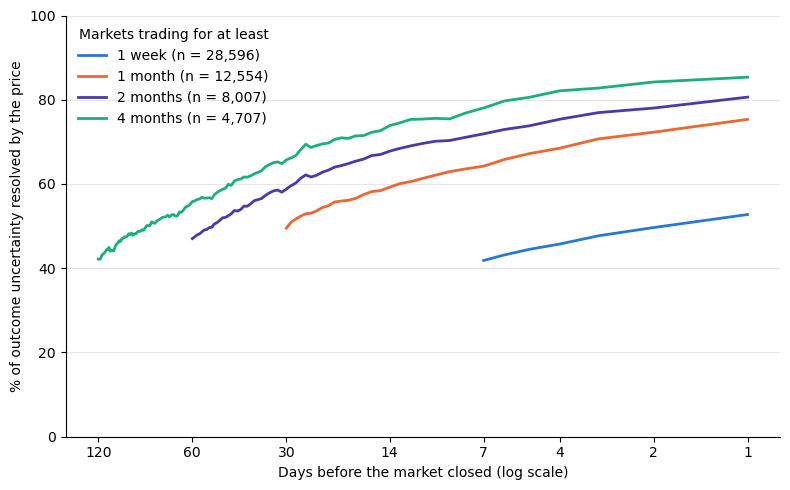

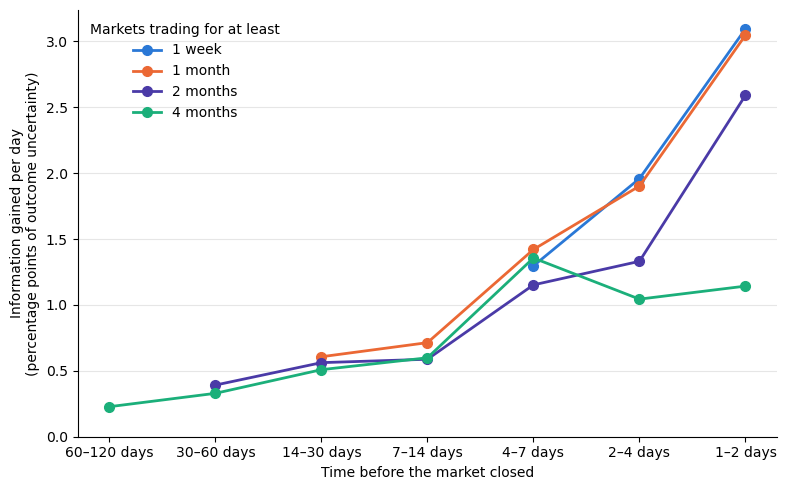

In [12]:
# one cohort per line: markets that traded for at least a week / a month / two months / four months
curves = {
    "1 week":   information_curve(panel, 7),
    "1 month":  information_curve(panel, 30),
    "2 months": information_curve(panel, 60),
    "4 months": information_curve(panel, 120),
}

# check: every cohort should have the same number of markets at every horizon.
# if min is well below max, some markets drop out near close (e.g. their price
# history stops early) and the short horizons use a different set of markets
for label, c in curves.items():
    print(f"{label}: markets per day between {c['n_markets'].min():,} and {c['n_markets'].max():,}")

fig, ax = plot_information_curves(curves)
fig.savefig(OUTPUT_DIR / "mutual_info.png", dpi=300, bbox_inches="tight")

fig, ax = plot_daily_gains(curves)
fig.savefig(OUTPUT_DIR / "change_in_info.png", dpi=300, bbox_inches="tight")

# numbers for the text / a table: the long cohort at a few horizons
curves["4 months"].loc[[1, 2, 4, 7, 14, 30, 60, 120]].round(4)

## Table 5: the four-month cohort with standard errors

`bootstrap_curve` resamples whole markets, so each bootstrap draw uses the same resampled markets at
every horizon, just like the estimate itself. That means anything built from the curve, such as the
gain per day between two horizons, also gets a valid standard error from the same draws.

Share of outcome uncertainty resolved at selected horizons. Four months out, prices already resolve
42% of the uncertainty, rising to 85% the day before close:

In [13]:
curve, pct_draws = bootstrap_curve(panel, 120)
curve.loc[[120, 60, 30, 14, 7, 4, 2, 1], ["mutual_info", "mutual_info_se",
                                          "pct_resolved", "pct_resolved_se"]].round(4)

,mutual_info,mutual_info_se,pct_resolved,pct_resolved_se
days_before,,,,
120,0.2519,0.0118,42.1551,1.6336
60,0.3336,0.0129,55.8325,1.7029
30,0.3926,0.0128,65.7148,1.5247
14,0.4413,0.0134,73.8574,1.4597
7,0.4660,0.0134,78.0510,1.3739
4,0.4899,0.0139,82.1203,1.3314
2,0.5024,0.0139,84.2088,1.2804
1,0.5096,0.0139,85.3519,1.2681


Information gained per day in each stretch, in percentage points of outcome uncertainty. The rate
rises from 0.23 points per day four to two months out to 1.36 between seven and four days before close.
In the last four days the estimates are too imprecise to tell whether learning keeps accelerating:
the 95% interval for the final day includes zero.

In [14]:
gains_per_day(curve, pct_draws).round(3)

,gain_per_day,se,ci_low,ci_high
stretch,,,,
60–120 days,0.228,0.024,0.185,0.275
30–60 days,0.329,0.035,0.260,0.397
14–30 days,0.509,0.065,0.387,0.635
7–14 days,0.599,0.125,0.347,0.839
4–7 days,1.356,0.255,0.912,1.904
2–4 days,1.044,0.311,0.394,1.635
1–2 days,1.143,0.588,-0.037,2.226
